In [ ]:
!pip install folium

In [ ]:
!pip install contextily

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import plotly.express as px


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = "/content/gdrive/MyDrive/MachineLearning/praktikum/prak11/"

In [ ]:
# membaca data file CSV
df = pd.read_csv(path + '/data/data.csv')
df.head()

,Unnamed: 0,id,foreign,name,lat,long
0,0,1101,11,KABUPATEN SIMEULUE,2.46158,96.38105
1,1,1102,11,KABUPATEN ACEH SINGKIL,2.28411,97.79769
2,2,1103,11,KABUPATEN ACEH SELATAN,3.26142,97.17933
3,3,1104,11,KABUPATEN ACEH TENGGARA,3.48673,97.81081
4,4,1105,11,KABUPATEN ACEH TIMUR,4.94789,97.77651


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  514 non-null    int64  
 1   id          514 non-null    int64  
 2   foreign     514 non-null    int64  
 3   name        514 non-null    object 
 4   lat         514 non-null    float64
 5   long        514 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 24.2+ KB


In [ ]:
df.head()

,Unnamed: 0,id,foreign,name,lat,long
0,0,1101,11,KABUPATEN SIMEULUE,2.46158,96.38105
1,1,1102,11,KABUPATEN ACEH SINGKIL,2.28411,97.79769
2,2,1103,11,KABUPATEN ACEH SELATAN,3.26142,97.17933
3,3,1104,11,KABUPATEN ACEH TENGGARA,3.48673,97.81081
4,4,1105,11,KABUPATEN ACEH TIMUR,4.94789,97.77651


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
id,0
foreign,0
name,0
lat,0
long,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# buat peta dasar indonesia
peta_indonesia = folium.Map(location=[-2.5, 118.0], zoom_start=5)
# buat list data dari latitude & longitude
data_heatmap = df[['lat', 'long']].values.tolist()
# tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=12, blur=15, max_zoom=6).add_to(peta_indonesia)
# tampilkan peta
peta_indonesia

In [ ]:
#1
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# Jitter koordinat agar tidak tumpang tindih
np.random.seed(42)
long_peta = df['long'] + np.random.uniform(-0.05, 0.05, size=len(df))
lat_peta  = df['lat']  + np.random.uniform(-0.05, 0.05, size=len(df))

# Konversi ke GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(long_peta, lat_peta),
    crs="EPSG:4326"
)

# Proyeksi ke Web Mercator
gdf = gdf.to_crs(epsg=3857)

# 5 wilayah paling utara (latitude tertinggi)
top_5 = df.sort_values(by='lat', ascending=False).head(5)

# 5 wilayah paling selatan (latitude terendah)
bottom_5 = df.sort_values(by='lat', ascending=True).head(5)

top_5, bottom_5


(    Unnamed: 0    id  foreign                  name      lat      long
 19          19  1172       11           KOTA SABANG  5.89285  95.32343
 18          18  1171       11       KOTA BANDA ACEH  5.54794  95.32080
 8            8  1109       11       KABUPATEN PIDIE  5.38550  95.96064
 7            7  1108       11  KABUPATEN ACEH BESAR  5.29718  95.61156
 17          17  1118       11  KABUPATEN PIDIE JAYA  5.22880  96.24542,
      Unnamed: 0    id  foreign                   name       lat       long
 305         305  5314       53    KABUPATEN ROTE NDAO -10.73864  123.12390
 311         311  5320       53  KABUPATEN SABU RAIJUA -10.55411  121.83349
 313         313  5371       53            KOTA KUPANG -10.17414  123.61184
 294         294  5303       53       KABUPATEN KUPANG -10.07183  123.86499
 293         293  5302       53  KABUPATEN SUMBA TIMUR  -9.98021  120.34355)

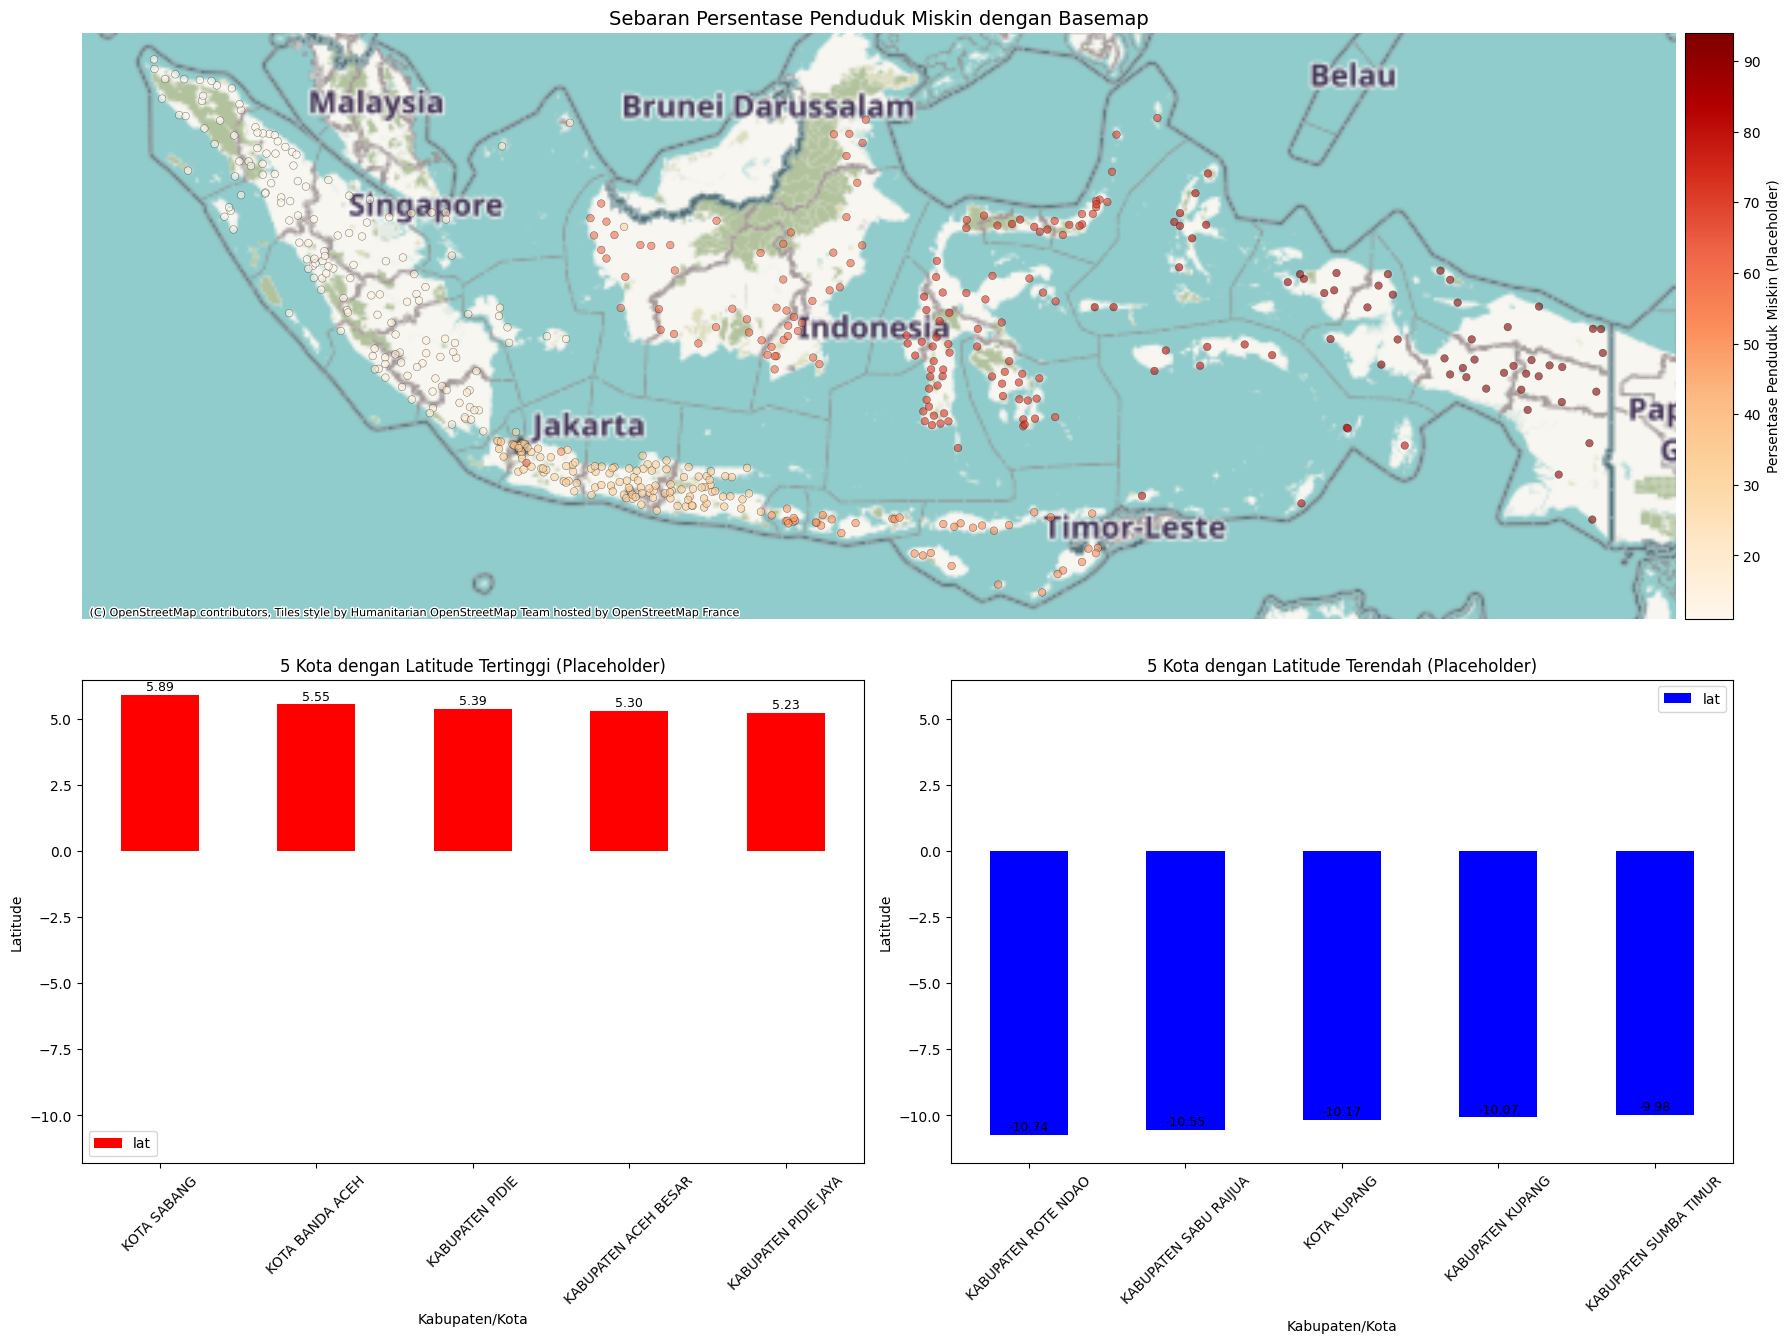

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

#Buat layout dengan GridSpec
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, height_ratios=[3,2])
# ---Row 1: Peta sebaran (colspan-2)---
ax_map = plt.subplot(gs[0, :]) # Use plt.subplot and span all columns in the first row
divider = make_axes_locatable(ax_map)
cax = divider.append_axes("right", size="3%", pad=0.1)

# NOTE: The column 'Persentase Penduduk Miskin' does not exist in your DataFrame (df.info()).
# Please ensure this column is available or use an existing one.
# For now, I will comment it out or use an existing column for demonstration if no other data is provided.
# Assuming 'foreign' column is used for demonstration, but you should replace it with your intended data.

gdf.plot(
    ax=ax_map,
    column =gdf['foreign'], # Changed to an existing column for demonstration, replace with actual data
    cmap = "OrRd",
    legend = True,
    legend_kwds={'label': "Persentase Penduduk Miskin (Placeholder)", 'orientation': "vertical"},
    cax=cax,
    markersize=30,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.6
)
ctx.add_basemap(ax_map)
ax_map.set_title("Sebaran Persentase Penduduk Miskin dengan Basemap", fontsize=14)
ax_map.axis('off')

# Row 2: Bar chart top & bottom (stacked vertically di satu kolon)
# Adjusting subplot indexing for a 2x2 grid: gs[1,0] for the first chart in the second row
ax_top = plt.subplot(gs[1, 0])
# Correcting syntax: kind="bar", ax=ax_top, color='red'
bars_top = top_5.plot(kind="bar", ax=ax_top, color='red', x='name', y='lat') # Using 'lat' as a placeholder for value
ax_top.set_title("5 Kota dengan Latitude Tertinggi (Placeholder)")
ax_top.set_ylabel("Latitude")
ax_top.set_xlabel("Kabupaten/Kota")
ax_top.tick_params(axis='x', rotation=45)

# You might want to add another subplot for bottom_5 in gs[1, 1]
# ax_bottom = plt.subplot(gs[1, 1])
# bottom_5.plot(kind="bar", ax=ax_bottom, color='blue', x='name', y='lat')
# ax_bottom.set_title("5 Kota dengan Latitude Terendah (Placeholder)")
# ax_bottom.set_ylabel("Latitude")
# ax_bottom.set_xlabel("Kabupaten/Kota")
# ax_bottom.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()